In [1]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import zscore

from tqdm import tqdm

import xml.etree.ElementTree as ET
from tifffile import imread
from tifffile import TiffFile

from skimage import io
from skimage.color import rgb2gray
from skimage.color import label2rgb
from skimage.transform import rescale
from skimage.exposure import rescale_intensity, equalize_adapthist
from skimage.measure import regionprops
from skimage.measure import regionprops_table
from skimage.segmentation import mark_boundaries
from skimage.filters import gaussian, median

from skimage.morphology import white_tophat, disk

# stardist
from csbdeep.utils import normalize
from stardist.models import StarDist2D

bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
2026-03-12 10:36:15.832287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
img_dir = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HYB04/original_data_test/"

imgs = {}

# counter = 0

for f in os.listdir(img_dir):
    # label = f.split('well')[1].split('_')[0]
    
    label = f.split("_")[1].split("_")[0]
    
    fullpath = f"{img_dir}{f}"
    
    img = imread(fullpath)
    imgs[label] = img
    
    # img_gray = extract_grayscale(img)
    # imgs[label] = img_gray
    
    print(f"{label} {img.shape=}")
    
#     counter += 1
#     if counter > 3:
#         break
    
print('\nDone!')

B6 img.shape=(3, 367, 498)
D2 img.shape=(3, 367, 498)
D6 img.shape=(3, 367, 498)
C5 img.shape=(3, 367, 498)
C4 img.shape=(3, 367, 498)

Done!


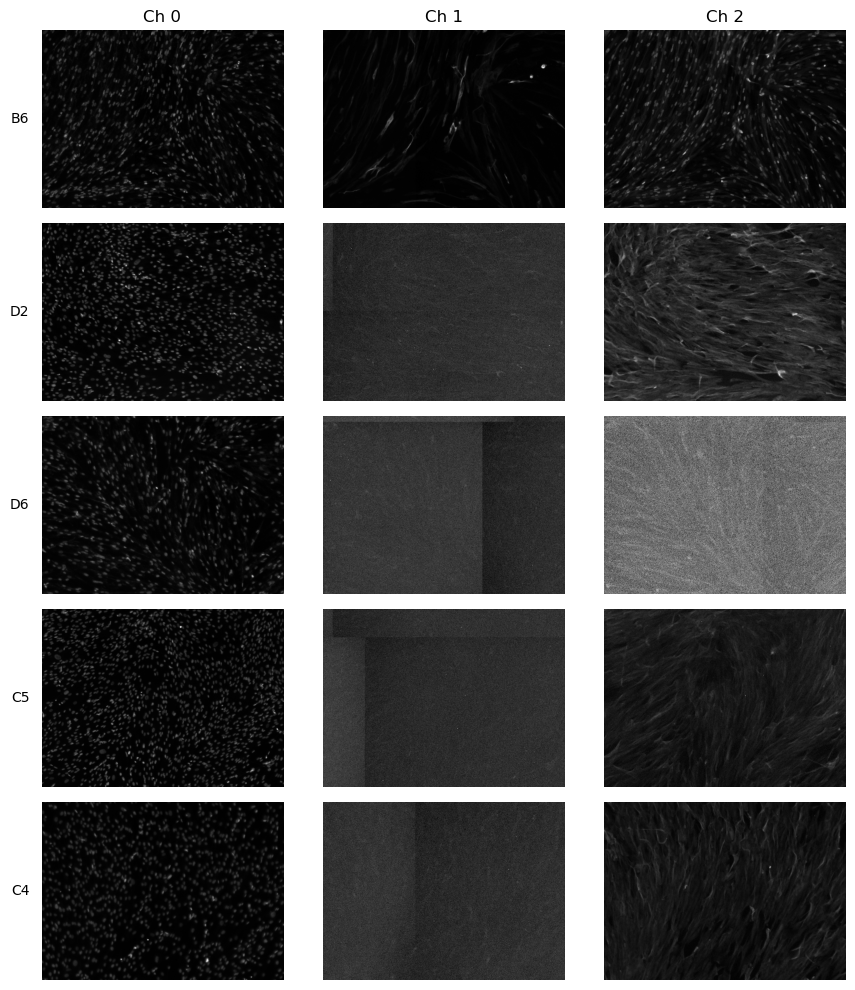

In [8]:
fig, axes = plt.subplots(5, 3, figsize=(3*3, 2*5))

for r, label in enumerate(imgs):
    img = imgs[label]   # shape (C,Y,X)

    for c in range(3):
        ax = axes[r, c] if 5 > 1 else axes[c]
        ax.imshow(img[c], cmap='gray')
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
# import logging
# logging.getLogger("tifffile").setLevel(logging.ERROR)


# def extract_grayscale(img):
#     """
#     Extract grayscale from (C, Y, X, 3) using the appropriate method per channel.
#     rgb2gray uses ITU-R 601-2 luma transform: 0.2126R + 0.7152G + 0.0722B
#     Output is scaled back to original dtype range.
#     """
#     gray_channels = []
#     vmax = np.iinfo(img.dtype).max

#     for c in range(img.shape[0]):
#         plane = img[c]  # (Y, X, 3)
#         gray  = rgb2gray(plane)           # float64 in [0, 1]
#         gray  = (gray * vmax).astype(img.dtype)
#         gray_channels.append(gray)

#         # print(f"Ch {c} ({info['channels'][c]}): "
#         #       f"min={gray.min()}, max={gray.max()}, "
#         #       f"mean={gray.mean():.2f}, nonzero={np.count_nonzero(gray)}")

#     return np.stack(gray_channels, axis=0)  # (C, Y, X)

# img_dir = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HYB04/images_day5/"

# raw_imgs = {}
# imgs = {}

# # counter = 0

# for f in os.listdir(img_dir):
#     label = f.split('well')[1].split('_')[0]
#     fullpath = f"{img_dir}{f}"
    
#     img = imread(fullpath)
#     raw_imgs[label] = img
    
#     img_gray = extract_grayscale(img)
#     imgs[label] = img_gray
    
#     print(f"{label} {img_gray.shape=}")
    
# #     counter += 1
# #     if counter > 3:
# #         break
    
# print('\nDone!')

E2 img_gray.shape=(3, 367, 498)
B5 img_gray.shape=(3, 367, 498)
D6 img_gray.shape=(3, 367, 498)
F3 img_gray.shape=(3, 367, 498)
F6 img_gray.shape=(3, 367, 498)
F4 img_gray.shape=(3, 367, 498)
B4 img_gray.shape=(3, 367, 498)
C5 img_gray.shape=(3, 367, 498)
B6 img_gray.shape=(3, 368, 498)
E4 img_gray.shape=(3, 367, 498)
B3 img_gray.shape=(3, 367, 498)
E5 img_gray.shape=(3, 367, 498)
E3 img_gray.shape=(3, 367, 498)
G6 img_gray.shape=(3, 367, 498)
G5 img_gray.shape=(3, 367, 498)
D3 img_gray.shape=(3, 367, 498)
C4 img_gray.shape=(3, 367, 498)
F5 img_gray.shape=(3, 367, 498)
C6 img_gray.shape=(3, 367, 498)
C3 img_gray.shape=(3, 367, 498)
E6 img_gray.shape=(3, 367, 498)
D2 img_gray.shape=(3, 367, 498)
D4 img_gray.shape=(3, 367, 498)
D5 img_gray.shape=(3, 367, 498)
F2 img_gray.shape=(3, 367, 498)
C2 img_gray.shape=(3, 367, 498)

Done!


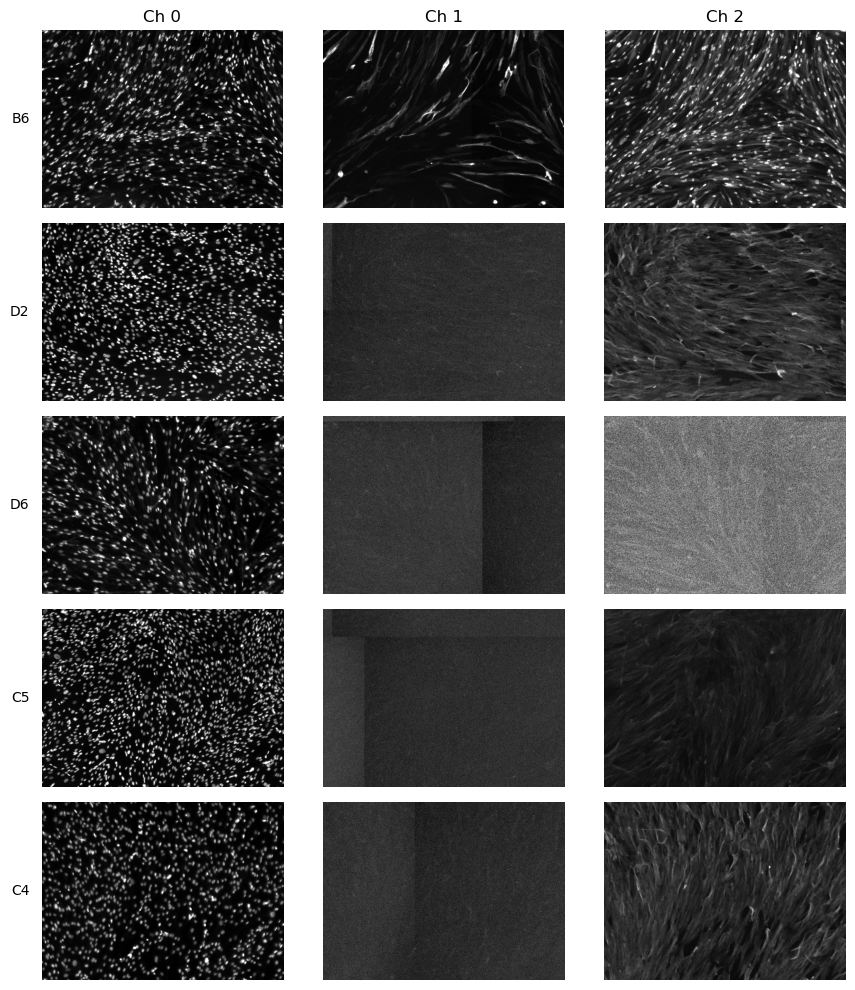

In [10]:
# test_imgs = ['B6', 'D2', 'D6', 'C5', 'C4']

# # labels = list(imgs.keys())
# n_rows = len(test_imgs)
# n_channels = 3

# fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows))

# for r, label in enumerate(test_imgs):
#     img = imgs[label]   # shape (C,Y,X)

#     for c in range(n_channels):
#         ax = axes[r, c] if n_rows > 1 else axes[c]
#         ax.imshow(img[c], cmap='gray')
#         ax.axis('off')

#         if r == 0:
#             ax.set_title(f'Ch {c}')
#         if c == 0:
#             ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)

# plt.tight_layout()
# plt.show()

In [12]:
# extract secondary only controls (grayscale)
# sec_only_1 = imgs['D5']
ref_background = imgs['D6']
# print(sec_only_1.shape)
print(ref_background.shape)

# average to get reference background
# sec_only = np.stack([sec_only_1, sec_only_2], axis=0) # 2, C, Y, X
# print(sec_only.shape)

# ref_background = sec_only.mean(axis=0).astype(sec_only_1.dtype)
# print(ref_background.shape)

print("Reference background per channel:")
for c in range(ref_background.shape[0]):
    print(f"  Ch {c}: "
          f"min={ref_background[c].min()}, "
          f"max={ref_background[c].max()}, "
          f"mean={ref_background[c].mean():.2f}")

(3, 367, 498)
Reference background per channel:
  Ch 0: min=586, max=14781, mean=1267.19
  Ch 1: min=622, max=1368, mean=768.43
  Ch 2: min=111, max=277, mean=182.96


In [13]:
def subtract_background_by_channel(img, ref_background, radius=10,
                                    per_image_channels=(0,),
                                    reference_channels=(1, 2)):
    """
    Apply different background subtraction strategies per channel.

    Parameters
    ----------
    img                 : ndarray, shape (C, Y, X) — image to correct
    ref_background      : ndarray, shape (C, Y, X) — reference background
    radius              : int, rolling ball radius for per-image channels
    per_image_channels  : tuple, channel indices to use per-image subtraction
    reference_channels  : tuple, channel indices to use reference subtraction

    Returns
    -------
    corrected : ndarray, same shape/dtype as img
    """
    selem     = disk(radius)
    corrected = np.zeros_like(img)

    for c in range(img.shape[0]):
        plane = img[c]

        if c in per_image_channels:
            # Rolling ball per-image (Hoechst)
            bg   = plane - white_tophat(plane, selem)
            corr = np.clip(
                       plane.astype(np.int32) - bg.astype(np.int32),
                       0, None
                   )
            # print(f"  Ch {c}: per-image subtraction")

        elif c in reference_channels:
            # Reference background subtraction (MyoD, MYH4)
            bg   = ref_background[c]
            corr = np.clip(
                       plane.astype(np.int32) - bg.astype(np.int32),
                       0, None
                   )
            # print(f"  Ch {c}: reference subtraction")

        else:
            corr = plane
            # print(f"  Ch {c}: no subtraction applied")

        corrected[c] = corr.astype(img.dtype)

    return corrected

In [15]:
corrected_imgs = {}
# composites = {}

radius = 10

# well B6 has diff shape (3, 368, ...); rest are (3, 367, ...)
# imgs['B6'] = imgs['B6'][:, :367, :]
# print(f"B6 shape after crop: {imgs['B6'].shape}")

for i, (label, image) in enumerate(imgs.items()):
    # background subtraction
    corr = subtract_background_by_channel(image, ref_background, radius=radius)
    corrected_imgs[label] = corr

    # create composite image (w/ color)
    # comp = build_composite(corr, channel_colors)
    # composites[label] = comp

In [16]:
def build_composite(corrected_gray, channel_colors, norm_max=None, per_image_channels=(0,)):
    composite = np.zeros((*corrected_gray.shape[1:], 3), dtype=np.float32)

    for c, color in enumerate(channel_colors):
        plane = corrected_gray[c].astype(np.float32)

        # Hoechst (or any per_image_channels) → always per-image normalization
        if c in per_image_channels:
            cmax = plane.max() if plane.max() > 0 else 1.0
        # All other channels → global reference max if provided
        elif norm_max is not None:
            cmax = norm_max[c] if norm_max[c] > 0 else 1.0
        else:
            cmax = plane.max() if plane.max() > 0 else 1.0

        if cmax == 0:
            print(f"Warning: Channel {c} is blank — skipping.")
            continue

        plane_norm = np.clip(plane / cmax, 0, 1)
        composite += plane_norm[..., np.newaxis] * color

    return np.clip(composite, 0, 1)

# Customize these to match your stains
lut_colors = {
    "red":     np.array([1, 0, 0]),
    "green":   np.array([0, 1, 0]),
    "blue":    np.array([0, 0, 1]),
    "cyan":    np.array([0, 1, 1]),
    "magenta": np.array([1, 0, 1]),
    "yellow":  np.array([1, 1, 0]),
    "gray":    np.array([1, 1, 1]),
}

# Assign a color to each channel — adjust to your stains
channel_colors = [
    lut_colors["blue"],    # Ch0 — e.g. DAPI
    lut_colors["green"],   # Ch1 — e.g. GFP
    lut_colors["red"],     # Ch2 — e.g. mCherry
]

# Rebuild composites with global normalization

# compute reference max signal from pos control
ref_well = 'B6'
ref_max = {c: corrected_imgs[ref_well][c].max() for c in range(3)}


composites = {
    label: build_composite(corr, channel_colors, norm_max=ref_max, per_image_channels=(0,))
    for label, corr in corrected_imgs.items()
}

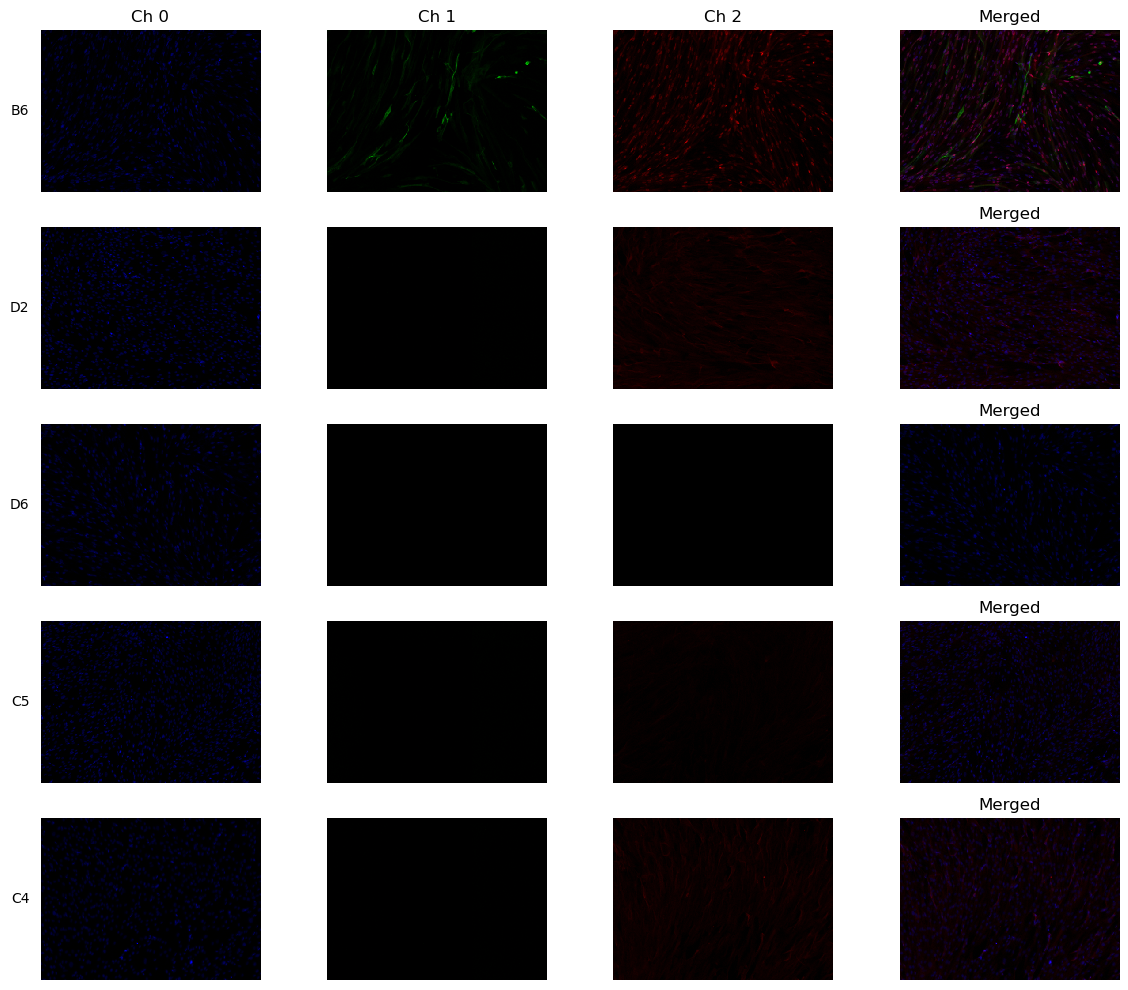

In [17]:
pixel_size_um  = 2.724 # pixel size in microns
scale_bar_length = 200 # microns

test_imgs = ['B6', 'D2', 'D6', 'C5', 'C4']

n_rows = len(test_imgs)
n_cols = 4 # each channel + composite


fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))

for r, label in enumerate(test_imgs):
    
    img = corrected_imgs[label]   # shape (C,Y,X)
    composite = composites[label]
    image_width_px = composite.shape[1]

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        
        # plane = img[c].astype(np.float32)
        # cmax = plane.max()
        # plane_norm = plane / cmax if cmax > 0 else plane
        # colorized = np.clip(plane_norm[..., np.newaxis] * channel_colors[c], 0, 1)
        
        plane = img[c].astype(np.float32)
        
        
        if c == 0:
            cmax = plane.max() if plane.max() > 0 else 1.0
        else:
            cmax = ref_max[c] if ref_max[c] > 0 else 1.0
        
        
        plane_norm = np.clip(plane / cmax, 0, 1)
        colorized = plane_norm[..., np.newaxis] * channel_colors[c]
        
        ax.imshow(colorized, interpolation='nearest')
        ax.axis('off')     
        
        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)
            
        # add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)
        
        # composite
        ax = axes[r, 3] if n_rows > 1 else axes[3]
        
        ax.imshow(composite, interpolation='nearest')
        ax.axis('off')
        ax.set_title("Merged")
        # add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.tight_layout()
plt.show()